# Unemployment Analysis with Python

## CodeAlpha Data Science Internship

### Objective

The objective of this project is to analyze unemployment rate data,
identify trends and patterns, investigate the impact of COVID-19 on
unemployment, and derive meaningful insights from the data using Python.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/malih/OneDrive/Desktop/Unemployment in India.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 7


In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.dtypes

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

In [10]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 196


In [12]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "percent")
)

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_percent', 'Estimated_Employed', 'Estimated_Labour_Participation_Rate_percent', 'Area']


In [14]:
df.head()

,Region,Date,Frequency,Estimated_Unemployment_Rate_percent,Estimated_Employed,Estimated_Labour_Participation_Rate_percent,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [15]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

df["Date"].head()

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]

In [16]:
print("Invalid dates:", df["Date"].isna().sum())

Invalid dates: 28


In [17]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2019-05-31 00:00:00
End date: 2020-06-30 00:00:00


In [18]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [19]:
print("Dataset shape before removing duplicates:", df.shape)

Dataset shape before removing duplicates: (768, 7)


In [20]:
df[df.duplicated()].head()

,Region,Date,Frequency,Estimated_Unemployment_Rate_percent,Estimated_Employed,Estimated_Labour_Participation_Rate_percent,Area
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [22]:
print("Regions:")
print(df["Region"].unique())
print("Areas:")
print(df["Area"].unique())
print("Frequency:")
print(df["Frequency"].unique())

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']
Areas:
['Rural' nan 'Urban']
Frequency:
[' Monthly' nan 'Monthly']


In [23]:
df["Area"].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [24]:
df[[
    "Estimated_Unemployment_Rate_percent",
    "Estimated_Employed",
    "Estimated_Labour_Participation_Rate_percent"
]].describe()

,Estimated_Unemployment_Rate_percent,Estimated_Employed,Estimated_Labour_Participation_Rate_percent
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [25]:
print("Minimum unemployment rate:",
      df["Estimated_Unemployment_Rate_percent"].min(), "%")

print("Maximum unemployment rate:",
      df["Estimated_Unemployment_Rate_percent"].max(), "%")

print("Average unemployment rate:",
      df["Estimated_Unemployment_Rate_percent"].mean(), "%")

Minimum unemployment rate: 0.0 %
Maximum unemployment rate: 76.74 %
Average unemployment rate: 11.787945945945946 %


In [26]:
print(
    df[
        (df["Estimated_Unemployment_Rate_percent"] < 0) |
        (df["Estimated_Unemployment_Rate_percent"] > 100)
    ]
)

Empty DataFrame
Columns: [Region, Date, Frequency, Estimated_Unemployment_Rate_percent, Estimated_Employed, Estimated_Labour_Participation_Rate_percent, Area]
Index: []


In [27]:
region_unemployment = (
    df.groupby("Region")["Estimated_Unemployment_Rate_percent"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated_Unemployment_Rate_percent, dtype: float64

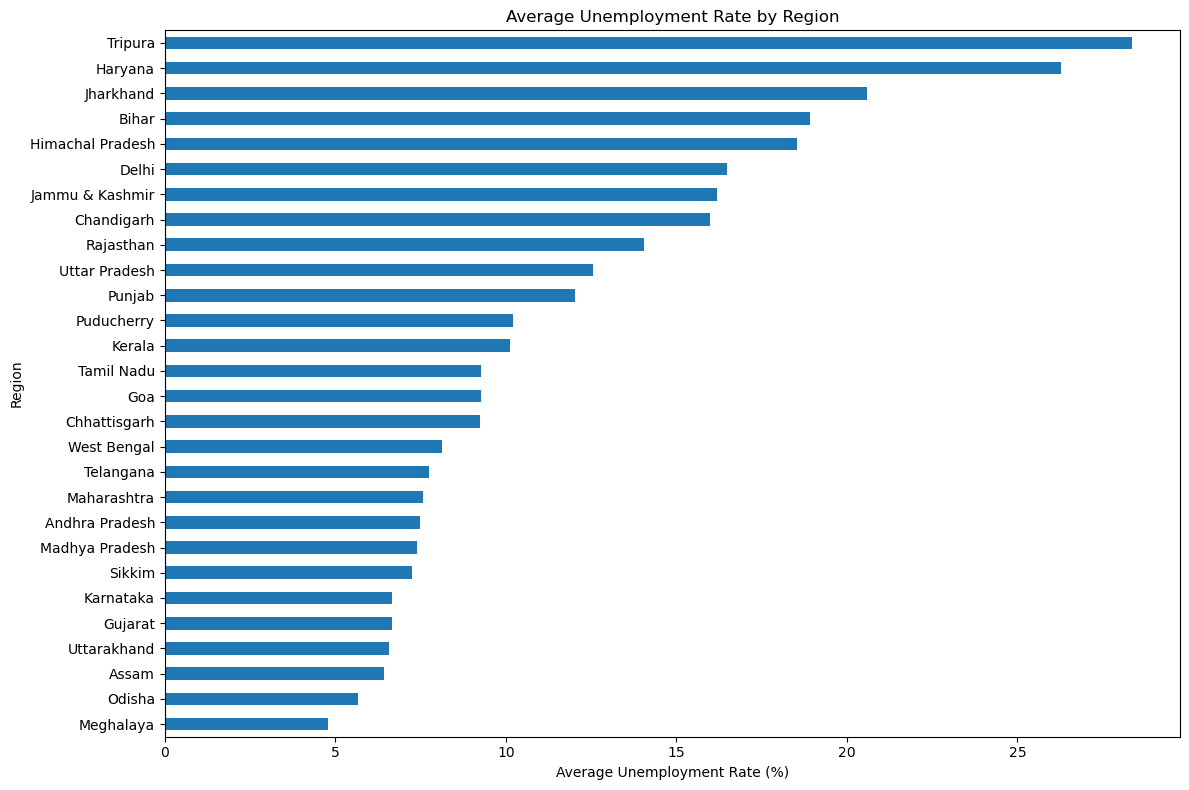

In [28]:
plt.figure(figsize=(12, 8))

region_unemployment.sort_values().plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [29]:
highest_region = region_unemployment.idxmax()
highest_rate = region_unemployment.max()

lowest_region = region_unemployment.idxmin()
lowest_rate = region_unemployment.min()

print("Highest average unemployment:")
print(highest_region, "-", round(highest_rate, 2), "%")

print("\nLowest average unemployment:")
print(lowest_region, "-", round(lowest_rate, 2), "%")

Highest average unemployment:
Tripura - 28.35 %

Lowest average unemployment:
Meghalaya - 4.8 %


In [30]:
area_unemployment = (
    df.groupby("Area")["Estimated_Unemployment_Rate_percent"]
    .mean()
)

area_unemployment

Area
Rural    10.324791
Urban    13.166614
Name: Estimated_Unemployment_Rate_percent, dtype: float64

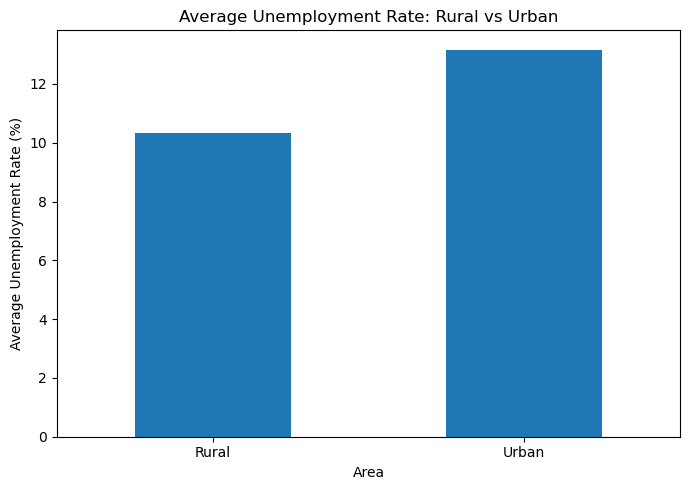

In [31]:
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
higher_unemployment_area = area_unemployment.idxmax()
higher_unemployment_rate = area_unemployment.max()

lower_unemployment_area = area_unemployment.idxmin()
lower_unemployment_rate = area_unemployment.min()

print(
    "Higher unemployment:",
    higher_unemployment_area,
    "-",
    round(higher_unemployment_rate, 2),
    "%"
)

print(
    "Lower unemployment:",
    lower_unemployment_area,
    "-",
    round(lower_unemployment_rate, 2),
    "%"
)

Higher unemployment: Urban - 13.17 %
Lower unemployment: Rural - 10.32 %


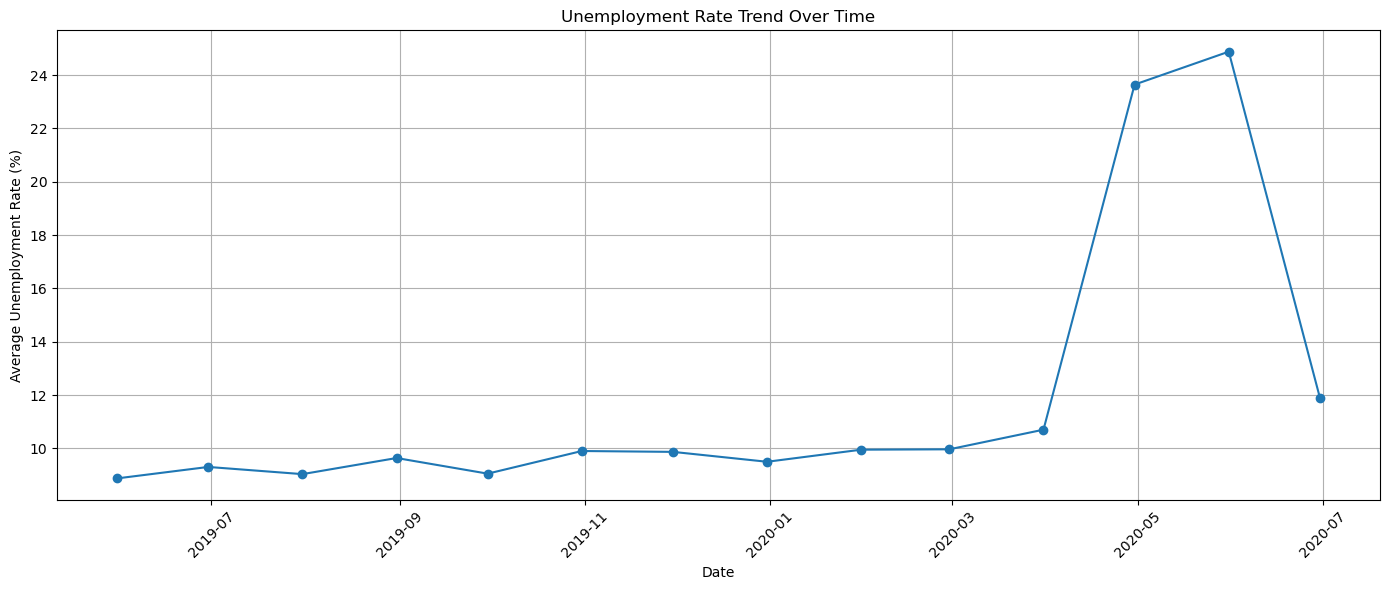

In [35]:
# Calculate average unemployment rate for each month
monthly_unemployment = (
    df.groupby("Date")["Estimated_Unemployment_Rate_percent"]
      .mean()
      .sort_index()
)

# Plot unemployment trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
highest_date = monthly_unemployment.idxmax()
highest_rate = monthly_unemployment.max()

lowest_date = monthly_unemployment.idxmin()
lowest_rate = monthly_unemployment.min()

print("Highest unemployment:")
print(highest_date.strftime("%B %Y"), "-", round(highest_rate, 2), "%")

print("\nLowest unemployment:")
print(lowest_date.strftime("%B %Y"), "-", round(lowest_rate, 2), "%")
df["Period"] = np.where(
    df["Date"] < "2020-03-01",
    "Before COVID-19",
    "During COVID-19"
)

df[["Date", "Period"]].head()

Highest unemployment:
May 2020 - 24.88 %

Lowest unemployment:
May 2019 - 8.87 %


,Date,Period
0,2019-05-31,Before COVID-19
1,2019-06-30,Before COVID-19
2,2019-07-31,Before COVID-19
3,2019-08-31,Before COVID-19
4,2019-09-30,Before COVID-19


In [38]:
covid_comparison = (
    df.groupby("Period")["Estimated_Unemployment_Rate_percent"]
      .mean()
)

print(covid_comparison)

Period
Before COVID-19     9.509534
During COVID-19    17.774363
Name: Estimated_Unemployment_Rate_percent, dtype: float64


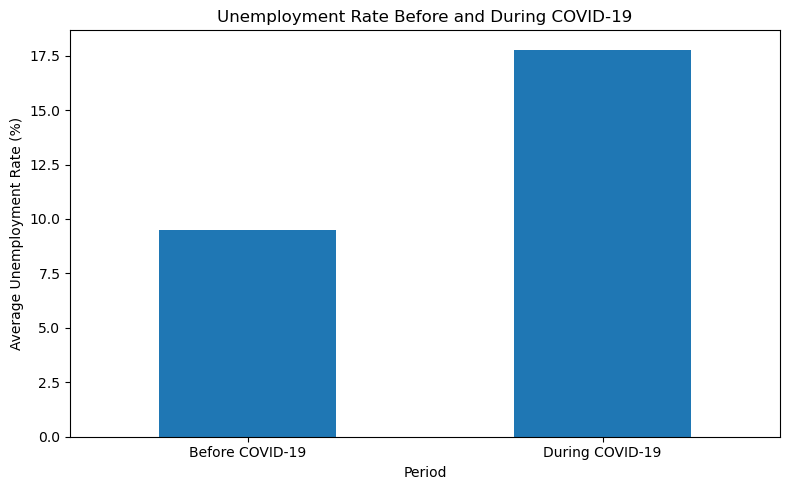

In [39]:
plt.figure(figsize=(8, 5))

covid_comparison.plot(kind="bar")

plt.title("Unemployment Rate Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
before_covid = covid_comparison["Before COVID-19"]
during_covid = covid_comparison["During COVID-19"]

change = during_covid - before_covid
percentage_change = (change / before_covid) * 100

print("Change in unemployment rate:",
      round(change, 2), "percentage points")

print("Percentage change:",
      round(percentage_change, 2), "%")

Change in unemployment rate: 8.26 percentage points
Percentage change: 86.91 %


In [41]:
df["Month"] = df["Date"].dt.month_name()

df[["Date", "Month"]].head()

,Date,Month
0,2019-05-31,May
1,2019-06-30,June
2,2019-07-31,July
3,2019-08-31,August
4,2019-09-30,September


In [42]:
monthly_pattern = (
    df.groupby("Month")["Estimated_Unemployment_Rate_percent"]
      .mean()
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_pattern = monthly_pattern.reindex(month_order)

monthly_pattern

Month
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Estimated_Unemployment_Rate_percent, dtype: float64

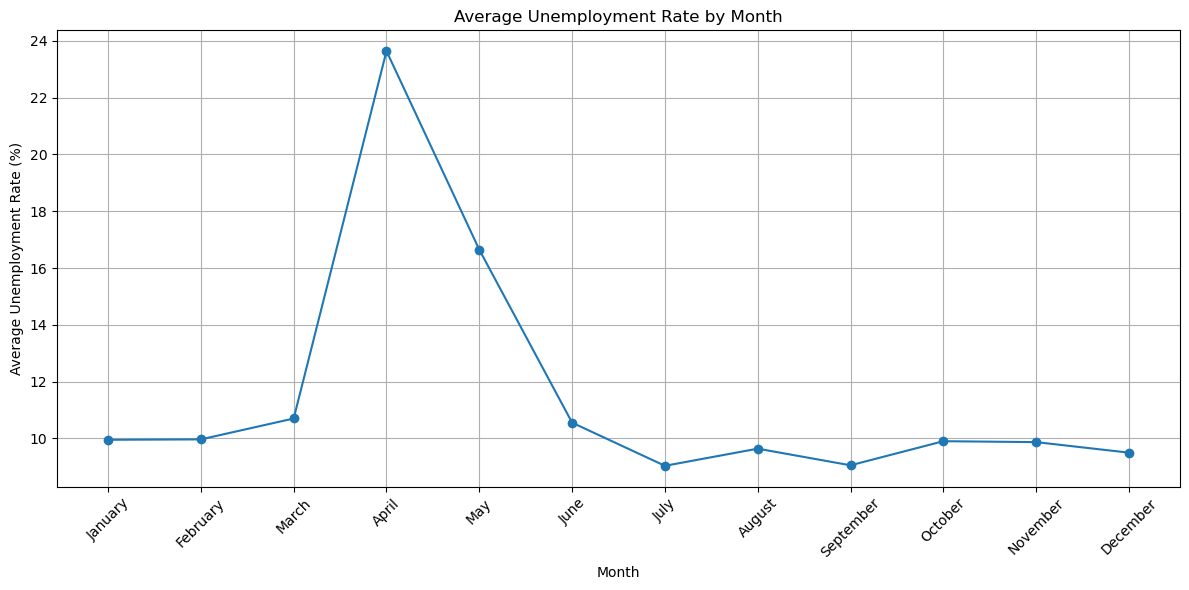

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
highest_month = monthly_pattern.idxmax()
highest_month_rate = monthly_pattern.max()

lowest_month = monthly_pattern.idxmin()
lowest_month_rate = monthly_pattern.min()

print(
    "Highest average unemployment month:",
    highest_month,
    "-",
    round(highest_month_rate, 2),
    "%"
)

print(
    "Lowest average unemployment month:",
    lowest_month,
    "-",
    round(lowest_month_rate, 2),
    "%"
)

Highest average unemployment month: April - 23.64 %
Lowest average unemployment month: July - 9.03 %


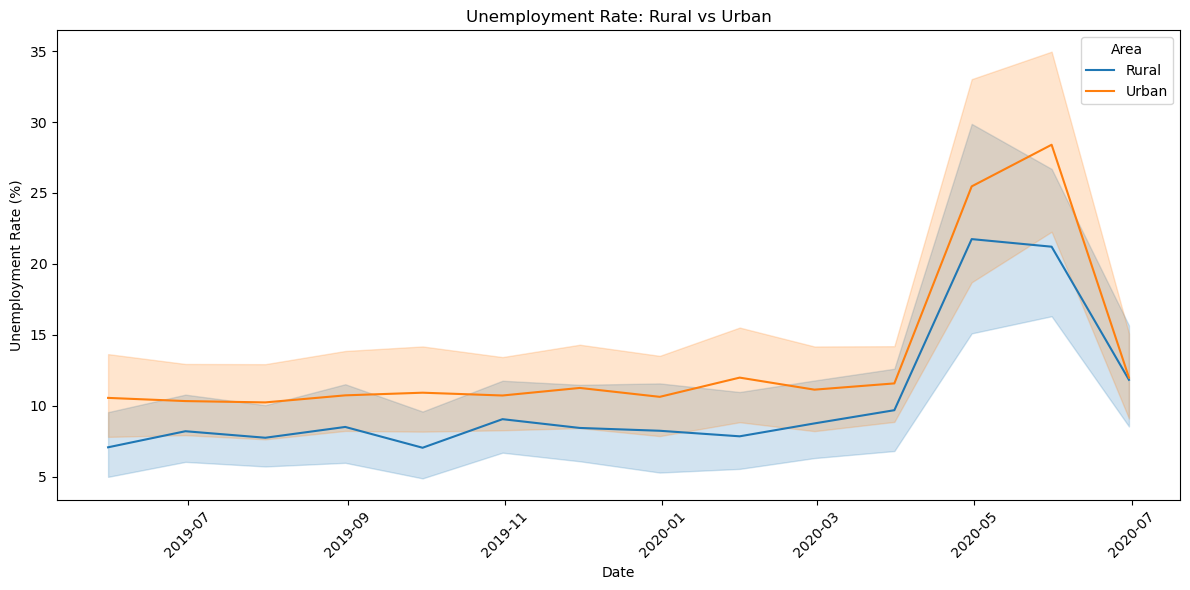

In [45]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated_Unemployment_Rate_percent",
    hue="Area"
)

plt.title("Unemployment Rate: Rural vs Urban")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Observations

- The unemployment rate varies considerably across different regions.
- Rural and Urban areas show differences in average unemployment rates.
- The unemployment rate changed noticeably during the COVID-19 period.
- Some regions experienced a larger increase in unemployment than others.
- Monthly analysis shows variations in unemployment rates over time.
- The dataset provides useful insights into regional and time-based unemployment patterns.

Conclusion

This analysis explored unemployment trends in India using Python. Data cleaning,
exploratory analysis, and visualizations were used to study regional, rural-urban,
monthly, and COVID-19-related unemployment patterns. The analysis shows that
unemployment varied across regions and changed significantly during the COVID-19
period.